# 🐢 Corner Time Loss Analysis
## `Barcelona` · `2026` Formula 1 World Championship

**Where is a driver losing lap time?** This notebook aligns two laps by track distance,
computes the cumulative **delta time**, and breaks it down **corner by corner**.

- **REFERENCE lap** = the benchmark / target (usually the faster lap)
- **COMPARE lap** = the lap you're analysing
- Where the delta curve **rises**, the compare lap is **losing time**.

**Comparison ideas:**
- Same driver, their fastest lap vs an earlier/worse lap → *where did I improve?*
- Driver vs teammate (same car) → *pure driving difference*
- Driver vs pole sitter → *where's the gap to the front?*

---

In [9]:
# ============================================================
# CONFIGURE
# ============================================================
YEAR       = 2026
GRAND_PRIX = 'Barcelona'
SESSION    = 'Q'        # 'Q' qualifying is ideal for clean single laps; 'R' also works

# REFERENCE lap (the benchmark — usually the faster one)
REF_DRIVER = 'HAM'
REF_LAP    = 'fastest'  # 'fastest' or a lap number e.g. 18

# COMPARE lap (the lap being analysed)
COMP_DRIVER = 'LEC'
COMP_LAP    = 'fastest'  # 'fastest' or a lap number
# ============================================================

In [10]:
import sys, os
from pathlib import Path

_here = Path(os.getcwd()).resolve()
_root = _here
for _ in range(5):
    if (_root / 'utils' / 'f1_helpers.py').exists():
        break
    _root = _root.parent
sys.path.insert(0, str(_root))

from utils.f1_helpers import (
    setup, ensure_assets_dir,
    get_lap, analyze_corners, plot_delta_trace, plot_corner_breakdown,
)
import fastf1

setup('content/f1_cache')
ASSETS = ensure_assets_dir('assets')

session = fastf1.get_session(YEAR, GRAND_PRIX, SESSION)
session.load(telemetry=True, weather=False)
print(f'\n✅ Loaded: {session.event["EventName"]} {YEAR} — {SESSION}')

core           INFO 	Loading data for Barcelona Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '44', '12', '1', '3', '6', '81', '30', '27', '16', '41', '5', '43', '10', '87', '55', '31', '23', '11', '77', '18', '14']



✅ Loaded: Barcelona Grand Prix 2026 — Q


In [11]:
lap_ref  = get_lap(session, REF_DRIVER, REF_LAP)
lap_comp = get_lap(session, COMP_DRIVER, COMP_LAP)

print(f'REFERENCE  {REF_DRIVER}  lap {int(lap_ref["LapNumber"])}  →  {lap_ref["LapTime"]}')
print(f'COMPARE    {COMP_DRIVER}  lap {int(lap_comp["LapNumber"])}  →  {lap_comp["LapTime"]}')

REFERENCE  HAM  lap 13  →  0 days 00:01:14.743000
COMPARE    LEC  lap 5  →  0 days 00:01:15.281000


e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"
e:\Projetos\f1\.venv\Lib\site-packages\fastf1\core.py:3129: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


---
## 1 · Run the delta analysis

In [12]:
analysis = analyze_corners(session, lap_ref, lap_comp)

# Per-corner table — positive TimeLost = COMPARE driver lost time in that corner
analysis['df']

e:\Projetos\f1\.venv\Lib\site-packages\fastf1\utils.py:85: FutureWarning: `utils.delta_time` is considered deprecated and willbe modified or removed in a future release because it hasa tendency to give inaccurate results.
  warnings.warn("`utils.delta_time` is considered deprecated and will"


,Corner,Distance,TimeLost,Cumulative
0,T1,815.502137,0.258297,0.258297
1,T2,899.533153,-0.160551,0.097746
2,T3,1147.708697,-0.011233,0.086513
3,T4,1712.631047,0.302272,0.388785
4,T5,2148.968259,0.099959,0.488744
5,T6,2344.656150,-0.001219,0.487524
6,T7,2506.958287,0.041859,0.529383
7,T8,2601.705432,0.006450,0.535833
8,T9,2868.538535,0.025857,0.561690
9,T10,3459.632602,0.057892,0.619582


---
## 2 · Speed trace + delta curve

Red shading = compare lap losing time · Green = gaining. Dotted lines mark corners.

Saved → assets\C1_delta_trace_HAM_vs_LEC.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_8828\2510998413.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


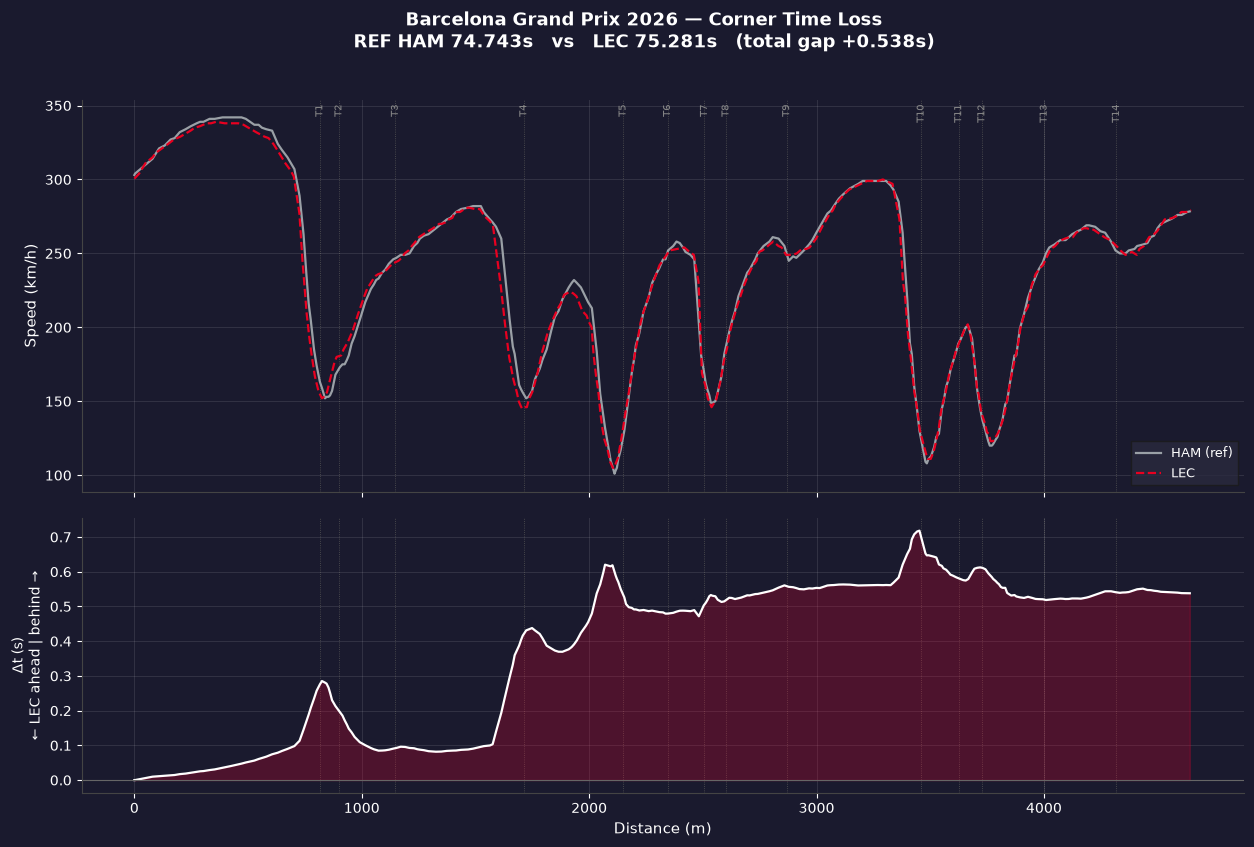

In [13]:
fig1 = plot_delta_trace(session, analysis, lap_ref, lap_comp, ASSETS)
fig1.show()

---
## 3 · Corner-by-corner breakdown

Saved → assets\C2_corner_breakdown_HAM_vs_LEC.png


C:\Users\Victor Borba\AppData\Local\Temp\ipykernel_8828\3636378035.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


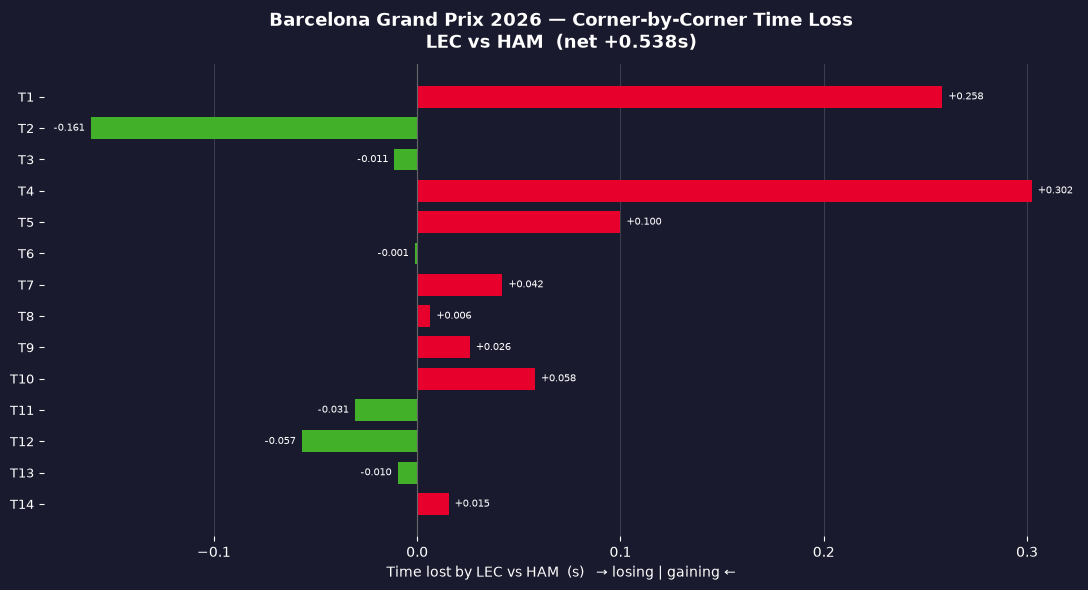

In [14]:
fig2 = plot_corner_breakdown(session, analysis, ASSETS)
fig2.show()

In [15]:
# The 5 corners costing the compare driver the most time
worst = analysis['df'].sort_values('TimeLost', ascending=False).head(5)
print(f'Top 5 corners where {COMP_DRIVER} loses time vs {REF_DRIVER}:\n')
for _, row in worst.iterrows():
    print(f"  {row['Corner']:>5}  {row['TimeLost']:+.3f}s")

Top 5 corners where LEC loses time vs HAM:

     T4  +0.302s
     T1  +0.258s
     T5  +0.100s
    T10  +0.058s
     T7  +0.042s


---
## 4 · LinkedIn Post Draft

In [16]:
df = analysis['df']
total = df['TimeLost'].sum()
worst = df.sort_values('TimeLost', ascending=False).head(3)
best  = df.sort_values('TimeLost').head(2)
event_name = session.event['EventName']

worst_str = ', '.join(f"{r['Corner']} ({r['TimeLost']:+.2f}s)" for _, r in worst.iterrows())
best_str  = ', '.join(f"{r['Corner']} ({r['TimeLost']:+.2f}s)" for _, r in best.iterrows())

post = f"""
🔬 {event_name} {YEAR} — Where does {COMP_DRIVER} lose time to {REF_DRIVER}?

I aligned both fastest laps by track distance and tracked the delta corner by corner.

Total gap: {total:+.3f}s

🔴 Biggest losses for {COMP_DRIVER}:
{worst_str}

🟢 Where {COMP_DRIVER} actually gained:
{best_str}

💡 [Your read — e.g. is it traction on exit? braking confidence? top speed?]

Method: FastF1 telemetry + delta-time analysis in Python. Code on GitHub 👇

#Formula1 #F1 #DataAnalysis #DataScience #Motorsport #FastF1 #Python #{event_name.replace(' ', '')}
"""

print(post)


🔬 Barcelona Grand Prix 2026 — Where does LEC lose time to HAM?

I aligned both fastest laps by track distance and tracked the delta corner by corner.

Total gap: +0.538s

🔴 Biggest losses for LEC:
T4 (+0.30s), T1 (+0.26s), T5 (+0.10s)

🟢 Where LEC actually gained:
T2 (-0.16s), T12 (-0.06s)

💡 [Your read — e.g. is it traction on exit? braking confidence? top speed?]

Method: FastF1 telemetry + delta-time analysis in Python. Code on GitHub 👇

#Formula1 #F1 #DataAnalysis #DataScience #Motorsport #FastF1 #Python #BarcelonaGrandPrix



---
## Assets generated

| File | Use for |
|------|---------|
| `C1_delta_trace_*.png` | Speed + delta curve — the technical centrepiece |
| `C2_corner_breakdown_*.png` | Corner bar chart — most shareable / readable |

**Commit:**
```bash
git add 2026/R{round}_{location}/
git commit -m "feat: {event_name} corner time-loss analysis"
git push
```